
# Introduction
Science fiction is a genre with roots and themes spanning back to the second century. However, the genre came to prominence in the mid-1800s, and has since only seen growth in popularity, with TV shows like Star Trek and Star Wars booming only a century later and shaping much of pop culture today. For this assignment, I will investigate classic, foundational works of science fiction from the early to mid 1800s.

### My Texts
*Frankenstein* by Mary Shelley (1818)

*The Last Man* by Mary Shelley (1826)

*The Mummy!* by Jane Loudon (1827)

### My Questions

>To what extent do Frankenstein and The Last Man exhibit similar linguistic patterns, and what differences might reflect their different subjects and narratives?

>Are the linguistic patterns in Mary Shelley's Frankenstein and The Last Man more similar to each other than to another novel from the same period?

### My Problems

* What metrics will make the most sense comparing two works of one author? 
* Will that differ to the best way of comparing those works to one work of a different author?
* How to determine meaningful *differences* between two works in a quantifiable way?

In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab
import requests, re
import operator
import nltk
from bs4 import BeautifulSoup
from collections import Counter
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bslessma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [159]:
import string

stop_words = nltk.corpus.stopwords.words('english') + [
 'ut', '\'re','.', ',', '--', '\'s', '?', ')', '(', ':', '\'',
 '\"', '-', '}', '{', '&', '|', u'\u2014' ]

def clean_word(wd):
    wd = wd.lower()
    wd = wd.strip(string.punctuation)
    return wd

# get rid of all the stuff above and below the book
def extract_book(text):
    start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
    end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"

    start = text.find(start_marker)
    end = text.find(end_marker)

    if start != -1 and end != -1:
        return text[start + len(start_marker):end]

    return text

# better for when I need to do the bigrams
def clean_text(text):
    text = extract_book(text)

    words = []
    for wd in text.split():
        wd = clean_word(wd)

        if wd not in stop_words:
            words.append(wd)

    return words

Frankenstein_txt = requests.get('https://www.gutenberg.org/ebooks/84.txt.utf-8').text
TheLastMan_txt = requests.get('https://www.gutenberg.org/ebooks/18247.txt.utf-8').text
TheMummy_txt = requests.get('https://www.gutenberg.org/ebooks/56426.txt.utf-8').text

Frankenstein_wds = clean_text(Frankenstein_txt)
TheLastMan_wds = clean_text(TheLastMan_txt)
TheMummy_wds = clean_text(TheMummy_txt)

In [160]:
# Graph Functions
def basic_graph(words, title, bigram=False):
    if not bigram:
        labels = [x[0] for x in words]
    else:
        labels = [' '.join(x[0]) for x in words]
    values = [x[1] for x in words]

    plt.figure(figsize=(5, 3))
    plt.barh(labels, values)
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.title(f"Most Frequent Words in {title}")
    plt.gca().invert_yaxis()
    plt.show()
    
def tornado_graph(top_words, values1, label1, values2, label2, bigram=False):
    # Reverse so largest words are toward the top
    top_words = top_words[::-1]
    values1 = values1[::-1]
    values2 = values2[::-1]

    # Normalized
    fig, ax = plt.subplots(figsize=(6, 5))

    y = np.arange(len(top_words))

    # LEFT
    ax.barh(y, [-x for x in values1], label=label1)

    # RIGHT
    ax.barh(y, values2, label=label2)

    if bigram:
        label=[' '.join(bigram) for bigram in top_words]
    else:
        label=top_words
        

    # Put word labels in the middle
    ax.set_yticks(y)
    ax.set_yticklabels(label)

    # Formatting
    ax.axvline(0, color="black", linewidth=0.8)

    ax.set_xlabel("Normalized Frequency")
    if bigram:
        ax.set_title(f"Normalized Bigram Frequency: {label1} vs. {label2}")
    else:
        ax.set_title(f"Normalized Word Frequency: {label1} vs. {label2}")

    ax.legend()

    plt.tight_layout()
    plt.show()

# Mary Shelley
I'll be looking at *Frankenstein* (1818) and *The Last Man* (1826)

Frankenstein
https://www.gutenberg.org/ebooks/84.txt.utf-8

The Last Man
https://www.gutenberg.org/ebooks/18247.txt.utf-8

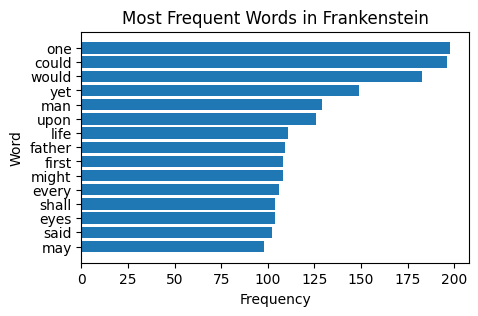

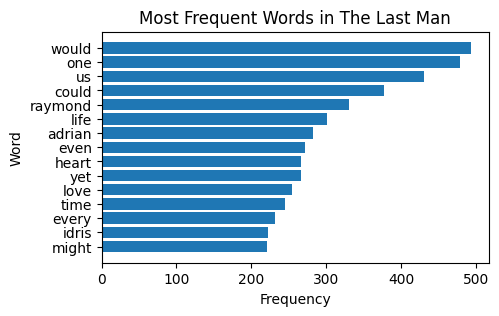

In [161]:
from nltk.util import ngrams
from matplotlib.lines import Line2D
from highlight_text import ax_text

# Raw Freq
Frankenstein_freq = Counter(Frankenstein_wds)
TheLastMan_freq = Counter(TheLastMan_wds)

# Most Frequent
words = Frankenstein_freq.most_common(15)
basic_graph(words, "Frankenstein")

words = TheLastMan_freq.most_common(15)
basic_graph(words, "The Last Man")


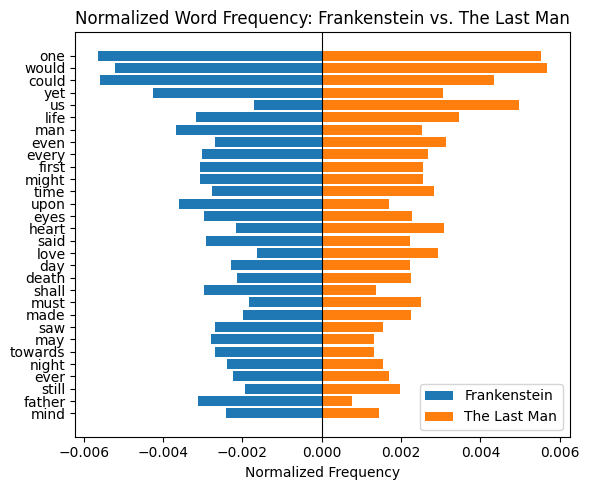

In [162]:
# Normalized Freq
total = sum(Frankenstein_freq.values())
Frankenstein_norm_freq = Counter({key: count / total for key, count in Frankenstein_freq.items()})

total = sum(TheLastMan_freq.values())
TheLastMan_norm_freq = Counter({key: count / total for key, count in TheLastMan_freq.items()})

# Get the top 30 words across BOTH books
all_words = set(Frankenstein_norm_freq) | set(TheLastMan_norm_freq)

combined = Counter({
    word: Frankenstein_norm_freq.get(word, 0) + TheLastMan_norm_freq.get(word, 0)
    for word in all_words
})

top_words = [word for word, freq in combined.most_common(30)]
frank_values = [Frankenstein_norm_freq.get(word, 0) for word in top_words]
lastman_values = [TheLastMan_norm_freq.get(word, 0) for word in top_words]

tornado_graph(top_words, frank_values, "Frankenstein", lastman_values, "The Last Man")

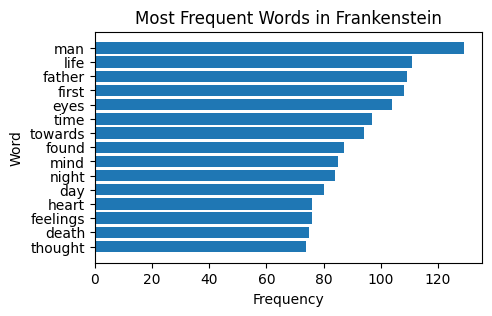

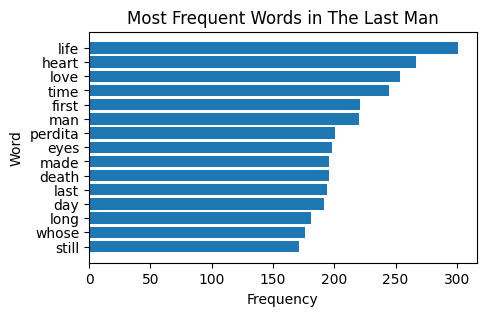

In [163]:

# Filtered
uninteresting_wds = [
    "would", "could", "said", "upon", "yet", "might", 
    "shall", "may", "one", "saw", "even", "felt", "ever", 
    "us", "must", "every", "raymond", "adrian", "elizabeth", 
    "idris", "edric", "rosabella", "roderick", "edmund", "elvira"]

Frankenstein_filtered = [
    wd for wd in Frankenstein_wds
    if wd not in uninteresting_wds
]
Frankenstein_filtered_freq = Counter(Frankenstein_filtered)

TheLastMan_filtered = [
    wd for wd in TheLastMan_wds
    if wd not in uninteresting_wds
]
TheLastMan_filtered_freq = Counter(TheLastMan_filtered)


# Filtered Graph
filtered = Frankenstein_filtered_freq.most_common(15)
basic_graph(filtered, "Frankenstein")

filtered = TheLastMan_filtered_freq.most_common(15)
basic_graph(filtered, "The Last Man")

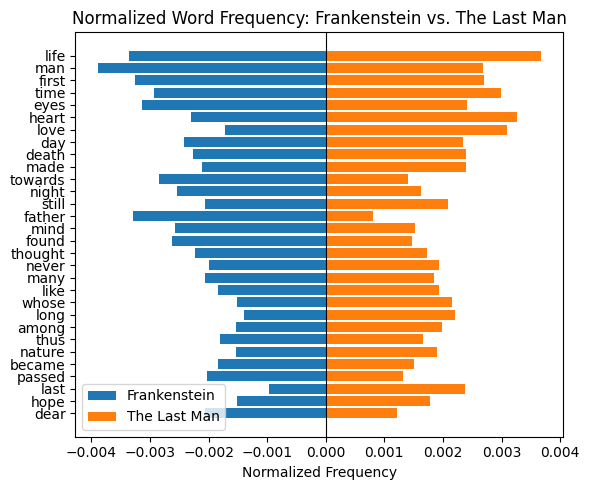

In [164]:
# Normalized + Filtered
# Normalized Freq
total = sum(Frankenstein_filtered_freq.values())
Frankenstein_norm_filtered_freq = Counter({key: count / total for key, count in Frankenstein_filtered_freq.items()})

total = sum(TheLastMan_filtered_freq.values())
TheLastMan_norm_filtered_freq = Counter({key: count / total for key, count in TheLastMan_filtered_freq.items()})

# Get the top 30 words across BOTH books
all_words = set(Frankenstein_norm_filtered_freq) | set(TheLastMan_norm_filtered_freq)

combined = Counter({
    word: Frankenstein_norm_filtered_freq.get(word, 0) + TheLastMan_norm_filtered_freq.get(word, 0)
    for word in all_words
})

top_words = [word for word, freq in combined.most_common(30)]
frank_values = [Frankenstein_norm_filtered_freq.get(word, 0) for word in top_words]
lastman_values = [TheLastMan_norm_filtered_freq.get(word, 0) for word in top_words]

tornado_graph(top_words, frank_values, "Frankenstein", lastman_values, "The Last Man")

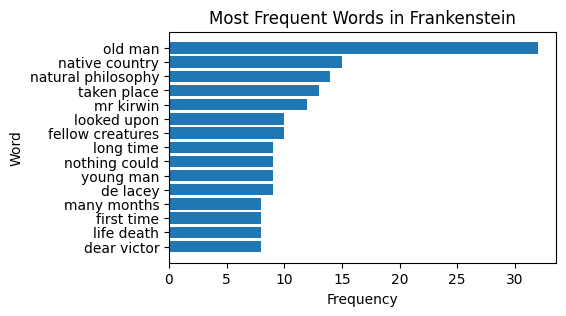

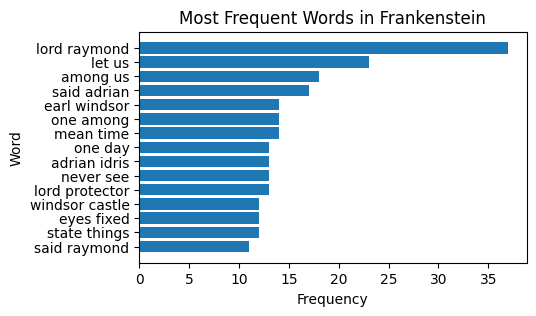

In [165]:
# Bigrams
Frankenstein_bi = Counter(ngrams(Frankenstein_wds, 2))
TheLastMan_bi = Counter(ngrams(TheLastMan_wds, 2))


# Bigrams
bigrams = Frankenstein_bi.most_common(15)
basic_graph(bigrams, "Frankenstein", bigram=True)

bigrams = TheLastMan_bi.most_common(15)
basic_graph(bigrams, "Frankenstein", bigram=True)

In [166]:
# Normalized + Bigrams

# Normalized Bigram Frequency Function (I just generic-ified some code I already had with AI rq 
# because I didn't want to copy paste this code and change every var)
def normalize_bi(wds1, name1, wds2, name2):
    # Normalize frequencies
    total1 = sum(wds1.values())
    norm_freq1 = Counter({
        key: count / total1 for key, count in wds1.items()
    })

    total2 = sum(wds2.values())
    norm_freq2 = Counter({
        key: count / total2 for key, count in wds2.items()
    })

    # Get bigrams that appear in BOTH books
    shared_bigrams = set(norm_freq1) & set(norm_freq2)

    # Rank shared bigrams by combined normalized frequency
    combined_shared = Counter({
        bigram: norm_freq1[bigram] + norm_freq2[bigram]
        for bigram in shared_bigrams
    })

    # Get the top shared bigrams
    top_bigrams = [
        bigram for bigram, freq in combined_shared.most_common(20)
    ]

    # Get normalized frequencies for each book
    values1 = [
        norm_freq1.get(bigram, 0)
        for bigram in top_bigrams
    ]
    values2 = [
        norm_freq2.get(bigram, 0)
        for bigram in top_bigrams
    ]


    # Make graph
    tornado_graph(top_bigrams, values1, name1, values2, name2, bigram=True)

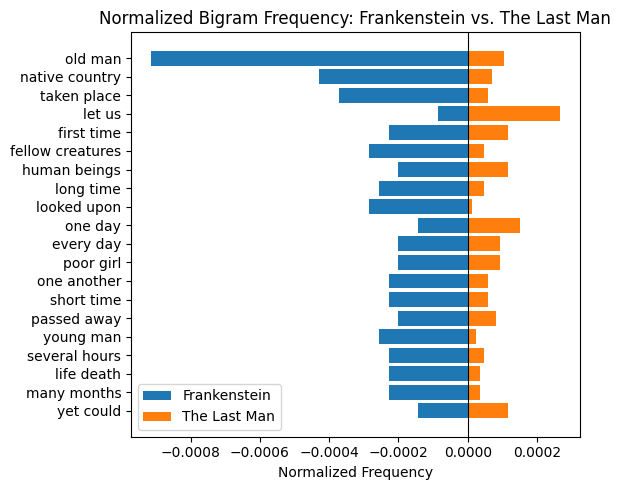

In [167]:
normalize_bi(Frankenstein_bi, "Frankenstein", TheLastMan_bi, "The Last Man")

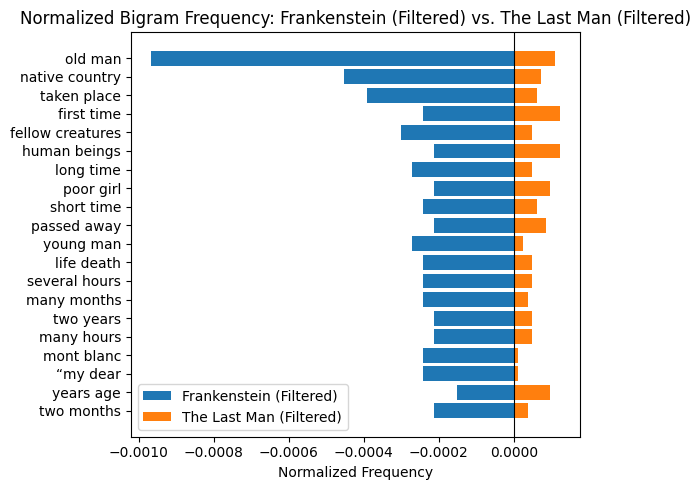

In [168]:
# Wanted to see if this would make a difference in the graph, but it didn't really.
Frankenstein_filtered_bi = Counter(ngrams(Frankenstein_filtered, 2))
TheLastMan_filtered_bi = Counter(ngrams(TheLastMan_filtered, 2))

normalize_bi(Frankenstein_filtered_bi, "Frankenstein (Filtered)", TheLastMan_filtered_bi, "The Last Man (Filtered)")

In [169]:
import statistics

def sentence_wds(text): 
    sentences = [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]

    total_sentences = len(sentences)
    total_words = sum(len(sentence.split()) for sentence in sentences)

    sentence_lengths = [len(sentence.split()) for sentence in sentences]

    if total_sentences > 0:
        avg_sentence_length = total_words / total_sentences
        median_sentence_length = statistics.median(sentence_lengths)
    else:
        avg_sentence_length = 0
        median_sentence_length = 0

    print(f"Total Sentences: {total_sentences}")
    print(f"Total Words: {total_words}")
    print(f"Average Sentence Length: {avg_sentence_length:.2f} words")
    print(f"Median Sentence Length: {median_sentence_length:.2f} words")
    
print("Frankenstein: ")
sentence_wds(Frankenstein_txt)

print("\nThe Last Man: ")
sentence_wds(TheLastMan_txt)

Frankenstein: 
Total Sentences: 3252
Total Words: 78106
Average Sentence Length: 24.02 words
Median Sentence Length: 21.00 words

The Last Man: 
Total Sentences: 6702
Total Words: 177656
Average Sentence Length: 26.51 words
Median Sentence Length: 23.00 words


#### Mary Shelley: Analysis

It appears that, although the length of these works varied wildly, Mary Shelley's sentence length is relatively consistent, adding only two more words both on average and in median per sentence. It is interesting how consistent her sentence length appears to be from work to work, with an apparently similar skew in both works for extra-long sentences as is shown in the small difference between average and median. She also appears to use pretty similar words between each work, with the tornado chart revealing somewhat equivalent numbers for her top 30 words across both works (skewed primarily one way by words like "father", which, for obvious reasons, appear a lot more in Frankenstein than The Last Man.) However, one key difference is that while she used similar words in each work, she didn't use similar phrasing, as her bigram frequency didn't seem to carry over from one novel to the next.

# Mary Shelley and Jane Loudon
Next, I'll compare these two works by Mary Shelley against a work by Jane Loudon published around the same time period (1827).

The Mummy! (1827)
https://www.gutenberg.org/ebooks/56426.txt.utf-8

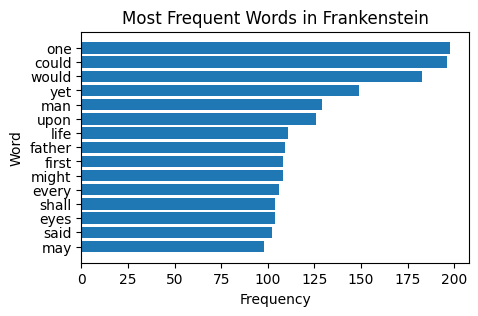

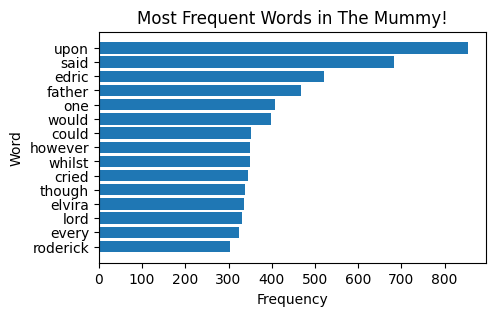

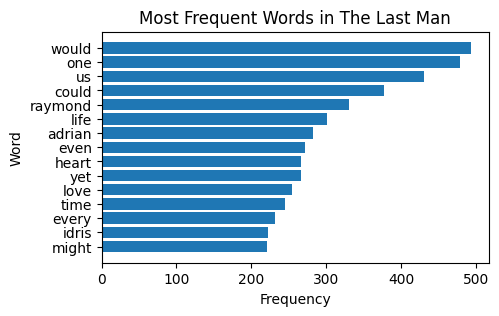

In [170]:
# Raw Freq
Mummy_freq = Counter(TheMummy_wds)

# Most Frequent
words = Frankenstein_freq.most_common(15)
basic_graph(words, "Frankenstein")

words = Mummy_freq.most_common(15)
basic_graph(words, "The Mummy!")

words = TheLastMan_freq.most_common(15)
basic_graph(words, "The Last Man")

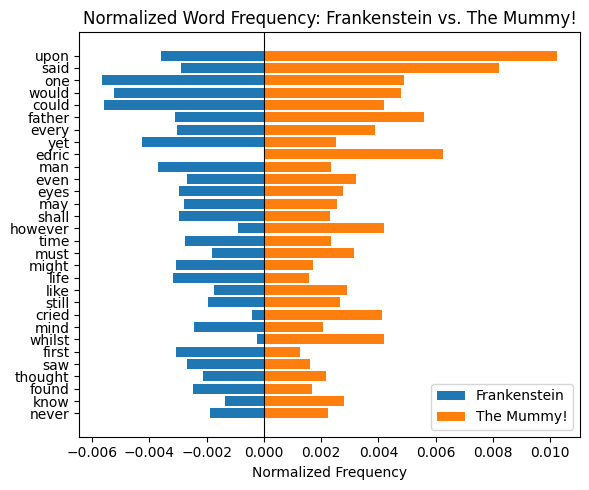

In [171]:
# Normalized Freq
total = sum(Mummy_freq.values())
Mummy_norm_freq = Counter({key: count / total for key, count in Mummy_freq.items()})


# Get the top 30 words across BOTH books
all_words = set(Frankenstein_norm_freq) | set(Mummy_norm_freq)

combined = Counter({
    word: Frankenstein_norm_freq.get(word, 0) + Mummy_norm_freq.get(word, 0)
    for word in all_words
})

top_words = [word for word, freq in combined.most_common(30)]
frank_values = [Frankenstein_norm_freq.get(word, 0) for word in top_words]
mummy_values = [Mummy_norm_freq.get(word, 0) for word in top_words]

tornado_graph(top_words, frank_values, "Frankenstein", mummy_values, "The Mummy!")

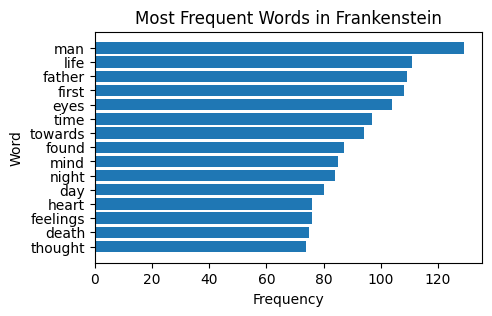

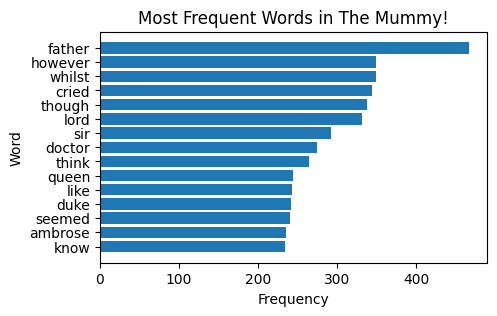

In [172]:
# Filtered
Mummy_filtered = [
    wd for wd in TheMummy_wds
    if wd not in uninteresting_wds
]
Mummy_filtered_freq = Counter(Mummy_filtered)


# Filtered Graph
filtered = Frankenstein_filtered_freq.most_common(15)
basic_graph(filtered, "Frankenstein")

filtered = Mummy_filtered_freq.most_common(15)
basic_graph(filtered, "The Mummy!")

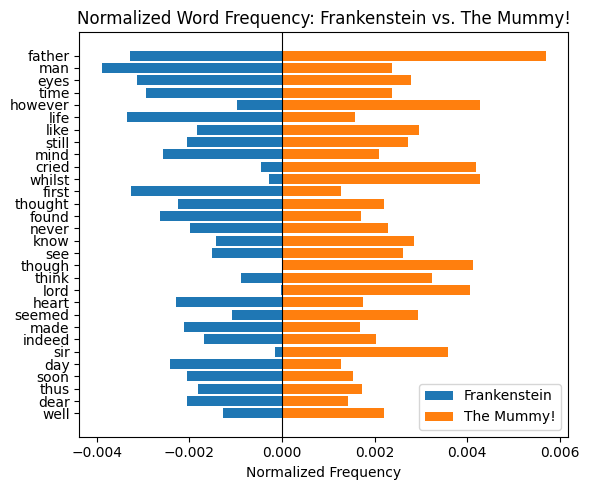

In [173]:
# Normalized + Filtered
total = sum(TheLastMan_filtered_freq.values())
Mummy_norm_filtered_freq = Counter({key: count / total for key, count in Mummy_filtered_freq.items()})

# Get the top 30 words across BOTH books
all_words = set(Frankenstein_norm_filtered_freq) | set(Mummy_norm_filtered_freq)

combined = Counter({
    word: Frankenstein_norm_filtered_freq.get(word, 0) + Mummy_norm_filtered_freq.get(word, 0)
    for word in all_words
})

top_words = [word for word, freq in combined.most_common(30)]
frank_values = [Frankenstein_norm_filtered_freq.get(word, 0) for word in top_words]
mummy_values = [Mummy_norm_filtered_freq.get(word, 0) for word in top_words]

tornado_graph(top_words, frank_values, "Frankenstein", mummy_values, "The Mummy!")

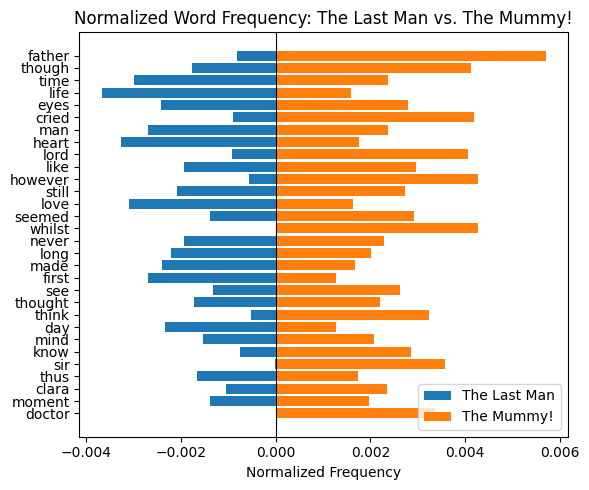

In [174]:
# Get the top 30 words across BOTH books
all_words = set(TheLastMan_norm_filtered_freq) | set(Mummy_norm_filtered_freq)

combined = Counter({
    word: TheLastMan_norm_filtered_freq.get(word, 0) + Mummy_norm_filtered_freq.get(word, 0)
    for word in all_words
})

top_words = [word for word, freq in combined.most_common(30)]
lastman_values = [TheLastMan_norm_filtered_freq.get(word, 0) for word in top_words]
mummy_values = [Mummy_norm_filtered_freq.get(word, 0) for word in top_words]

tornado_graph(top_words, lastman_values, "The Last Man", mummy_values, "The Mummy!")

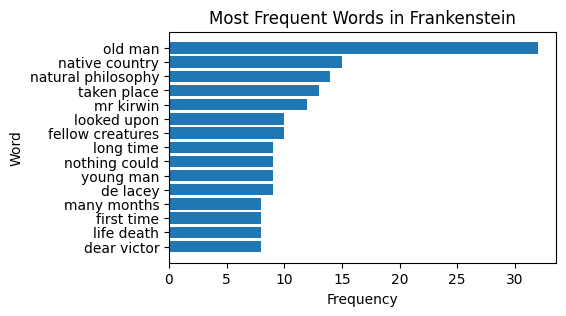

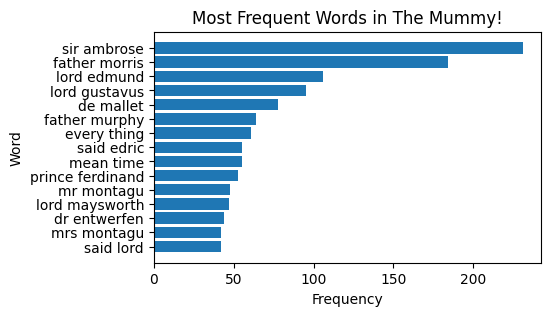

In [175]:
# Bigrams
Mummy_bi = Counter(ngrams(TheMummy_wds, 2))

# Bigrams
bigrams = Frankenstein_bi.most_common(15)
basic_graph(bigrams, "Frankenstein", bigram=True)

bigrams = Mummy_bi.most_common(15)
basic_graph(bigrams, "The Mummy!", bigram=True)

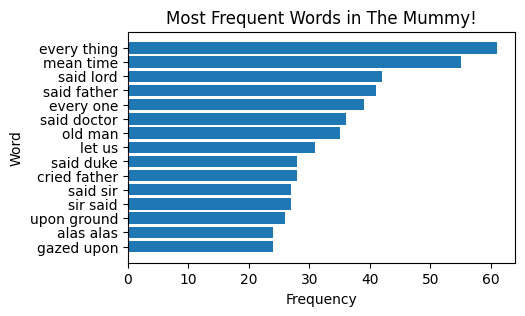

In [176]:
# There are too many darn names in this book.
mum_filter = [
    'ambrose', 'morris', 'gustavus', 'mallet', 'murphy', 'ferdinand', 'montagu', 'maysworth', 
    'entwerfen', 'montagu', 'coleman', 'hardman', 'clara', 'edmund', 'edric', 'seymour']
Mummy_filtered_2 = [
    wd for wd in TheMummy_wds
    if wd not in mum_filter
]

Mummy_filtered_bi_2 = Counter(ngrams(Mummy_filtered_2, 2))
bigrams = Mummy_filtered_bi_2.most_common(15)
basic_graph(bigrams, "The Mummy!", bigram=True)

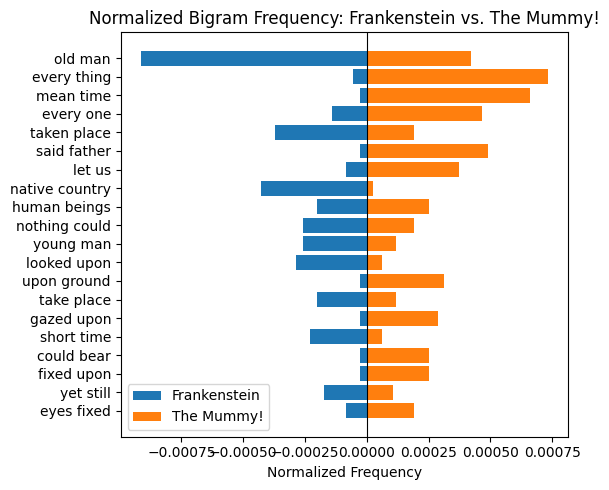

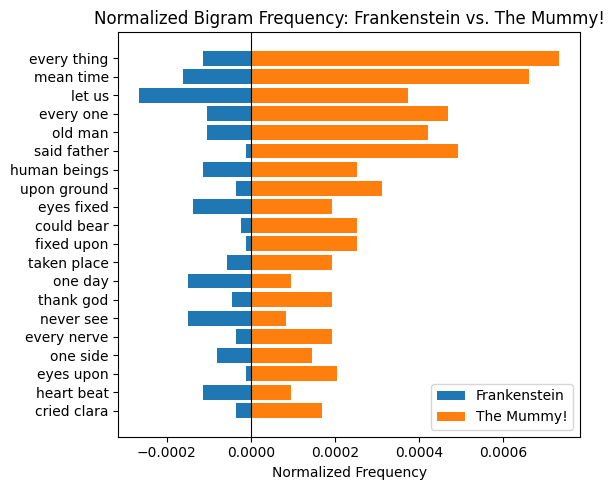

In [177]:
# Normalized + Bigrams
normalize_bi(Frankenstein_bi, "Frankenstein", Mummy_bi, "The Mummy!")
normalize_bi(TheLastMan_bi, "Frankenstein", Mummy_bi, "The Mummy!")

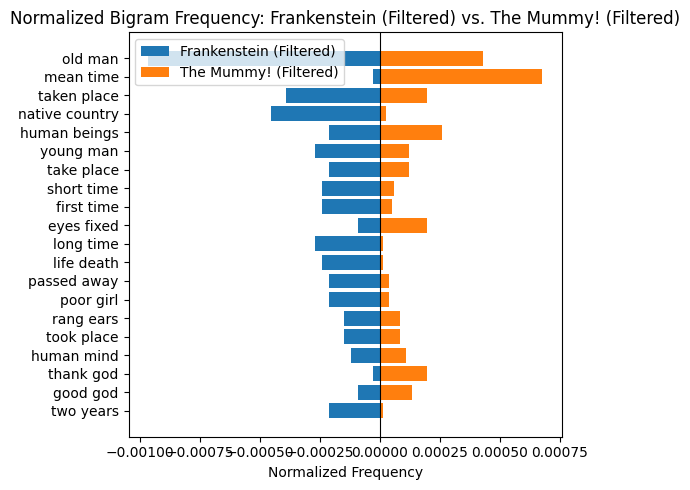

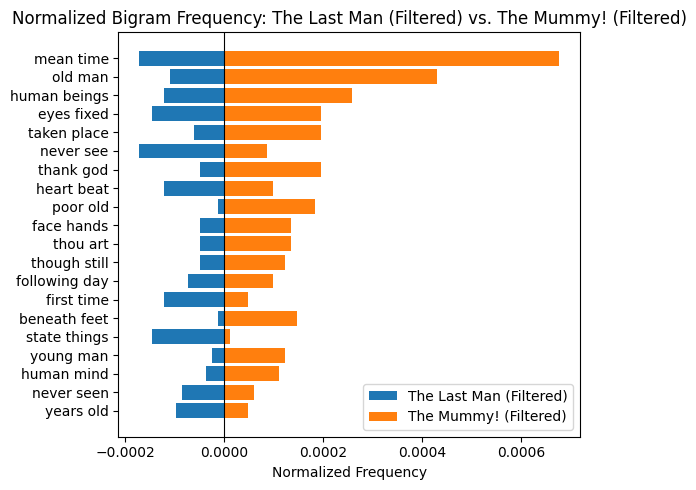

In [178]:
normalize_bi(Frankenstein_filtered_bi, "Frankenstein (Filtered)", Mummy_filtered_bi_2, "The Mummy! (Filtered)")
normalize_bi(TheLastMan_filtered_bi, "The Last Man (Filtered)", Mummy_filtered_bi_2, "The Mummy! (Filtered)")

In [179]:
print("Frankenstein: ")
sentence_wds(Frankenstein_txt)
print("\nThe Last Man: ")
sentence_wds(TheLastMan_txt)
print("\nThe Mummy!: ")
sentence_wds(TheMummy_txt)

Frankenstein: 
Total Sentences: 3252
Total Words: 78106
Average Sentence Length: 24.02 words
Median Sentence Length: 21.00 words

The Last Man: 
Total Sentences: 6702
Total Words: 177656
Average Sentence Length: 26.51 words
Median Sentence Length: 23.00 words

The Mummy!: 
Total Sentences: 6029
Total Words: 169882
Average Sentence Length: 28.18 words
Median Sentence Length: 23.00 words


#### Jane Loudon vs. Mary Shelley:Analysis

While the averages and medians for *Frankenstein*, *The Last Man*, and *The Mummy!* are all very similar to one another, it's interesting how big the gap is between median and average for The Mummy! compared to the other two (Frankenstein and The Last Man both only having a two word difference, while The Mummy has a five word difference.) This would indicate to me that, while all three works have a comparable sentence length generally speaking, The Mummy! has more instances of very long sentences that skew the average. Also interestingly, when comparing the normalized frequency of both indvidual words and bigrams, both of Mary Shelley's works tended to have a similar range of frequencies (both sides capping out at around .006 for individual words and .004 for bigrams). However, when we compare these same works to Jane Loudon, there tends to be a larger disparity in frequency (single word frequency capping out at around .004 for Mary Shelley while Jane Loudon's works capped at .006), and there seemed to be less symmetry in the graphs, indicating that words that were typically used frequently in Mary Shelley's work were not prevalent in The Mummy. I think this demonstrates that even at the numerical, data-verifiable level, there is a clear difference in their writing styles, vocabulary, and technique, and perhaps somewhat disproves my theory that there would be a shared lexicon between them from which Sci-Fi would begin to shape its roots.

(Also, one more interesting thing as someone who hasn't read any of these books - The Last Man and The Mummy! apparently both happen to have a character named Clara. I guess it was popular at the time?)

This last section was just my curiosity getting to the better of me, wondering if there was a way to directly compare the three at the same time. I decided to include it because I think it's interesting - you can really see how, despite the differences, as a general trend, Mary Shelley's works tend to have the same values where The Mummy! diverges wildly. (Also, if you look closely, it looks like where The Last Man diverges from Frankenstein, it tends to be closer to The Mummy, which might be a sign of the time passing? But I digress - there's no hard numbers of that, and I think it's just my monkey brain seeking out patterns where there is none.) 

I'm not including this as 'official homework' since I had AI write this code based off my previous functions and I think it's not a perfect way to show this (it's not super intuitive at first what you're supposed to take away from this), so this is just a fun little inclusion :)

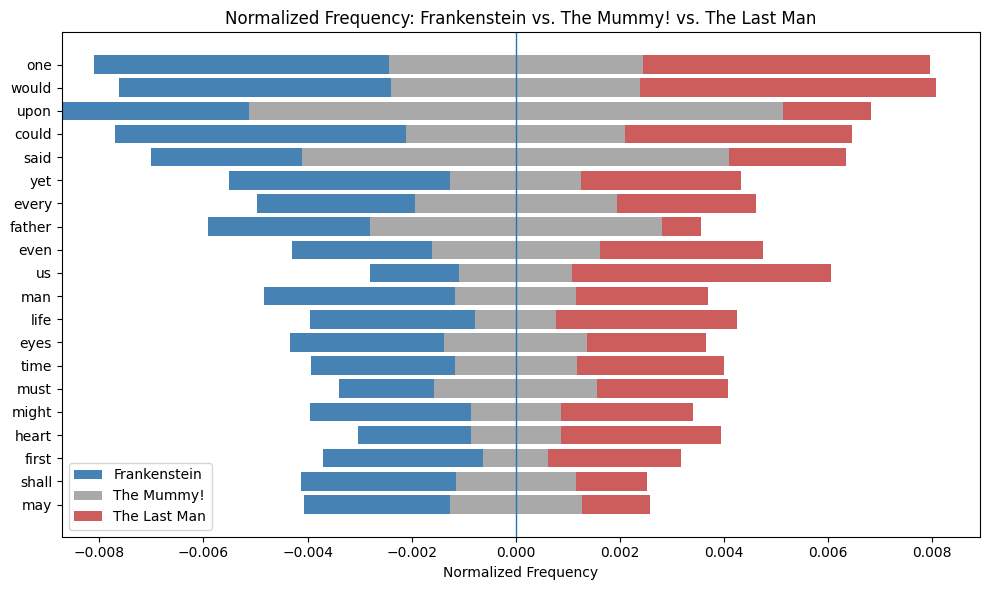

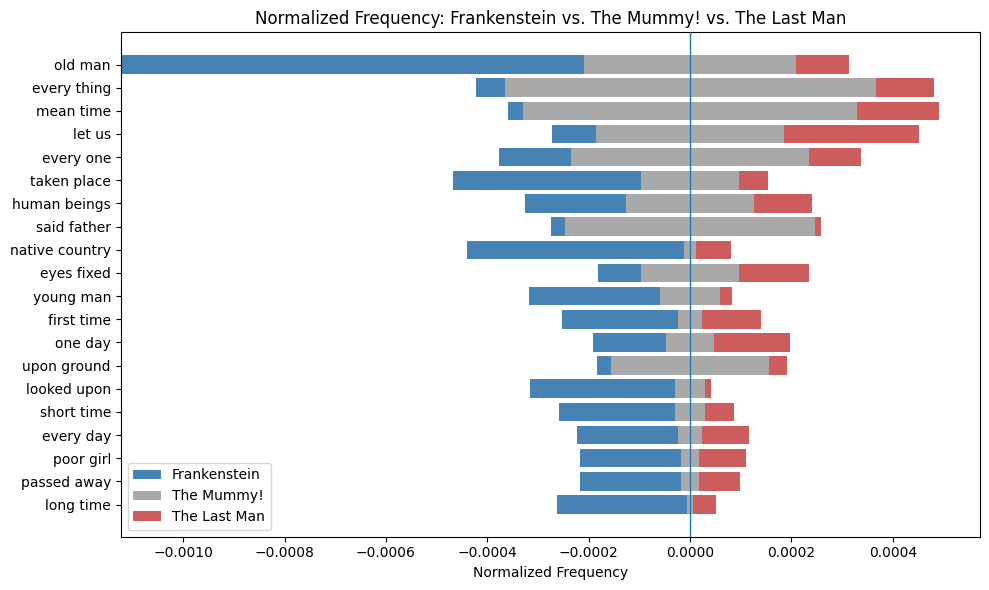

In [180]:
def three_way_tornado(items, values1, name1, values2, name2, values3, name3,
                      bigram=False, title=None):

    # Reverse so the highest-frequency items appear at the top
    items = items[::-1]
    values1 = values1[::-1]
    values2 = values2[::-1]
    values3 = values3[::-1]

    y = np.arange(len(items))

    fig, ax = plt.subplots(figsize=(10, 6))

    for i, (v1, v2, v3) in enumerate(zip(values1, values2, values3)):

        # Frankenstein: LEFT
        ax.barh(
            i,
            v1,
            left=-(v1 + v2 / 2),
            color="steelblue",
            label=name1 if i == 0 else ""
        )

        # The Mummy: CENTER
        ax.barh(
            i,
            v2,
            left=-v2 / 2,
            color="darkgray",
            label=name2 if i == 0 else ""
        )

        # The Last Man: RIGHT
        ax.barh(
            i,
            v3,
            left=v2 / 2,
            color="indianred",
            label=name3 if i == 0 else ""
        )

    # Center line
    ax.axvline(0, linewidth=1)

    # Format labels
    if bigram:
        labels = [" ".join(item) for item in items]
    else:
        labels = [str(item) for item in items]

    ax.set_yticks(y)
    ax.set_yticklabels(labels)

    ax.set_xlabel("Normalized Frequency")

    if title is None:
        title = f"Normalized Frequency: {name1} vs. {name2} vs. {name3}"

    ax.set_title(title)

    ax.legend()

    plt.tight_layout()
    plt.show()
    
def normalize_three(wds1, name1, wds2, name2, wds3, name3,
                    top_n=20, bigram=False, title=None):

    # Normalize Frankenstein
    total1 = sum(wds1.values())
    norm_freq1 = Counter({
        key: count / total1
        for key, count in wds1.items()
    })

    # Normalize The Mummy
    total2 = sum(wds2.values())
    norm_freq2 = Counter({
        key: count / total2
        for key, count in wds2.items()
    })

    # Normalize The Last Man
    total3 = sum(wds3.values())
    norm_freq3 = Counter({
        key: count / total3
        for key, count in wds3.items()
    })

    # Get terms that appear in ALL THREE books
    shared_terms = (
        set(norm_freq1)
        & set(norm_freq2)
        & set(norm_freq3)
    )

    # Rank shared terms by their combined normalized frequency
    combined_shared = Counter({
        term: (
            norm_freq1[term]
            + norm_freq2[term]
            + norm_freq3[term]
        )
        for term in shared_terms
    })

    # Get top terms
    top_terms = [
        term
        for term, freq in combined_shared.most_common(top_n)
    ]

    # Get frequencies for each book
    values1 = [
        norm_freq1.get(term, 0)
        for term in top_terms
    ]

    values2 = [
        norm_freq2.get(term, 0)
        for term in top_terms
    ]

    values3 = [
        norm_freq3.get(term, 0)
        for term in top_terms
    ]

    # Make graph
    three_way_tornado(
        top_terms,
        values1,
        name1,
        values2,
        name2,
        values3,
        name3,
        bigram=bigram,
        title=title
    )
    
normalize_three(
    Frankenstein_freq,
    "Frankenstein",
    Mummy_freq,
    "The Mummy!",
    TheLastMan_freq,
    "The Last Man",
    bigram=False
)

normalize_three(
    Frankenstein_bi,
    "Frankenstein",
    Mummy_bi,
    "The Mummy!",
    TheLastMan_bi,
    "The Last Man",
    bigram=True
)